In [1]:
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps trl peft accelerate bitsandbytes


  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-m6cv559z/unsloth_c5d9814847464a90ae5cac92d0b09ee7
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-m6cv559z/unsloth_c5d9814847464a90ae5cac92d0b09ee7
  Resolved https://github.com/unslothai/unsloth.git to commit 997f1a7ce5fb7a0319c2b8abe0e7af02e2160efe
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.2/395.2 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.9/181.9 kB 21.4 MB/s eta 0:00:00


In [2]:
import sys
sys.exit()

SystemExit: 

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [3]:
from huggingface_hub import login
from google.colab import userdata, drive

login(token=userdata.get('HF_TOKEN'))
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit",
    max_seq_length = 2048,
    load_in_4bit = True
)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.4: Fast Qwen2 patching. Transformers: 5.2.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-7b-instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [6]:
model = FastLanguageModel.get_peft_model(
    model,
    r= 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                     "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
)

Unsloth 2026.3.4 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


In [ ]:
!ls "/content/drive/MyDrive/Colab Notebooks/"


In [7]:
from datasets import load_dataset

dataset = load_dataset("json", data_files = "/content/drive/MyDrive/Colab Notebooks/Datasets/datasetnew.jsonl", split="train")

#formateamos los datos

def formating_data(data):
    texts = []

    for i in range(len(data['prompt'])):
        text = f"### User: \n{data['prompt'][i]}\n### Asistant:\n{data['response'][i]}<|endoftext|>"
        texts.append(text)

    return {"text": texts}

dataset = dataset.map(formating_data, batched= True)

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/4512 [00:00<?, ? examples/s]

In [8]:
from transformers import TrainingArguments
from trl import SFTTrainer
import torch

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = 2048,
    dataset_num_proc = 2,
    packing = False,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 60,
        learning_rate = 2e-4, # Corrected: 'learning_Rate' to 'learning_rate'
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 1, # Corrected: 'logging_Steps' to 'logging_steps'
        output_dir = "outputs",
        optim = "adamw_8bit",
        seed = 0,
    )
)

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/4512 [00:00<?, ? examples/s]

In [9]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 4,512 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)


Step,Training Loss
1,3.157774
2,2.987728
3,2.923358
4,2.920337
5,2.575133
6,2.444423
7,2.219228
8,2.355712
9,2.564460
10,2.478894


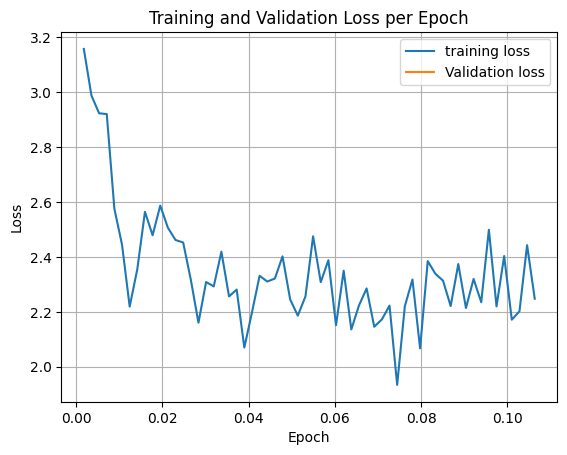

In [10]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_losses = [log["loss"] for log in log_history if "loss" in log]
epoch_train = [log["epoch"] for log in log_history if "loss" in log]
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
epoch_eval = [log["epoch"] for log in log_history if "eval_loss" in log]


plt.plot(epoch_train, train_losses, label = "training loss")
plt.plot(epoch_eval, eval_losses, label = "Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
model.save_pretrained("/content/drive/MyDrive/Colab Notebooks/Models/modelo_qwen")
tokenizer.save_pretrained("/content/drive/MyDrive/Colab Notebooks/Models/modelo_qwen")

('/content/drive/MyDrive/Colab Notebooks/Models/modelo_qwen/tokenizer_config.json',
 '/content/drive/MyDrive/Colab Notebooks/Models/modelo_qwen/chat_template.jinja',
 '/content/drive/MyDrive/Colab Notebooks/Models/modelo_qwen/tokenizer.json')

In [13]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "/content/drive/MyDrive/Colab Notebooks/Models/modelo_qwen",
    max_seq_length = 2048,
    load_in_4bit = True
)

==((====))==  Unsloth 2026.3.4: Fast Qwen2 patching. Transformers: 5.2.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

unsloth/qwen2.5-7b-instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [18]:
FastLanguageModel.for_inference(model) #modo inferencia

inputs = tokenizer(["### Usuario:\nNo confié en mi esposa cuando descubrí que tenía un nuevo amigo al que le escribía y llamaba. Lo investigué antes de descubrir que era gay y que no había nada. Ahora mi esposa y yo solo discutimos sobre la confianza.\n### Asistente:\n"], return_tensors = "pt").to("cuda")

outputs = model.generate(**inputs, max_new_tokens = 256)
print(tokenizer.decode(outputs[0]))

### Usuario:
No confié en mi esposa cuando descubrí que tenía un nuevo amigo al que le escribía y llamaba. Lo investigué antes de descubrir que era gay y que no había nada. Ahora mi esposa y yo solo discutimos sobre la confianza.
### Asistente:
El primer paso para resolver este problema es hablar con ella, pero eso puede ser difícil. En lugar de enfocarse en lo que ella hizo, puedes hablar de cómo te sentiste al descubrirlo. Esto ayudará a que el tema no sea acusatorio y también te ayudará a liberar tus emociones. Luego puedes preguntarle si tiene algo que agregar a su lado de la historia. Siéntate y escucha. Ella puede tener una explicación razonable. No puedes controlar los actos de otra persona, pero puedes controlar tu reacción. La confianza es importante, pero la comunicación también. Puedes empezar a construir la confianza de nuevo si ambos están dispuestos a trabajar en ello.<|endoftext|>
